### [ 히스토그램과 평탄화 ] <hr>

- 픽셀값이 집중된 부분도 있고 흩어져 있는 부분들도 존재=> 정규화 사용 시 효과가 떨어짐
- 개선 방안=> 픽셀 빈도가 전체에 차지하는 비중 기반으로 변환하는 기법=> 평탄화
- 조건
    * 반드시 그레이스케일 1채널만 가능함
    * 컬러 이미지=> 그레이스케일 이미지로 변환, HSV/YUV로 변환 후 밝기 채널, 즉 V/Y 채널 사용

In [1]:
## --------------------------
## 모듈 로딩
## --------------------------

import cv2
import os
import matplotlib.pyplot as plt
import koreanize_matplotlib
import numpy as np
import matplotlib.cm as cm
import sys
sys.path.append(r"C:\KDT14\7_CV")
import cv_utils


In [3]:
import importlib
import cv_utils

importlib.reload(cv_utils)

from cv_utils import printPlotImage
importlib.reload(cv_utils)

from cv_utils import printPlotImage

cdf shape: (256,)


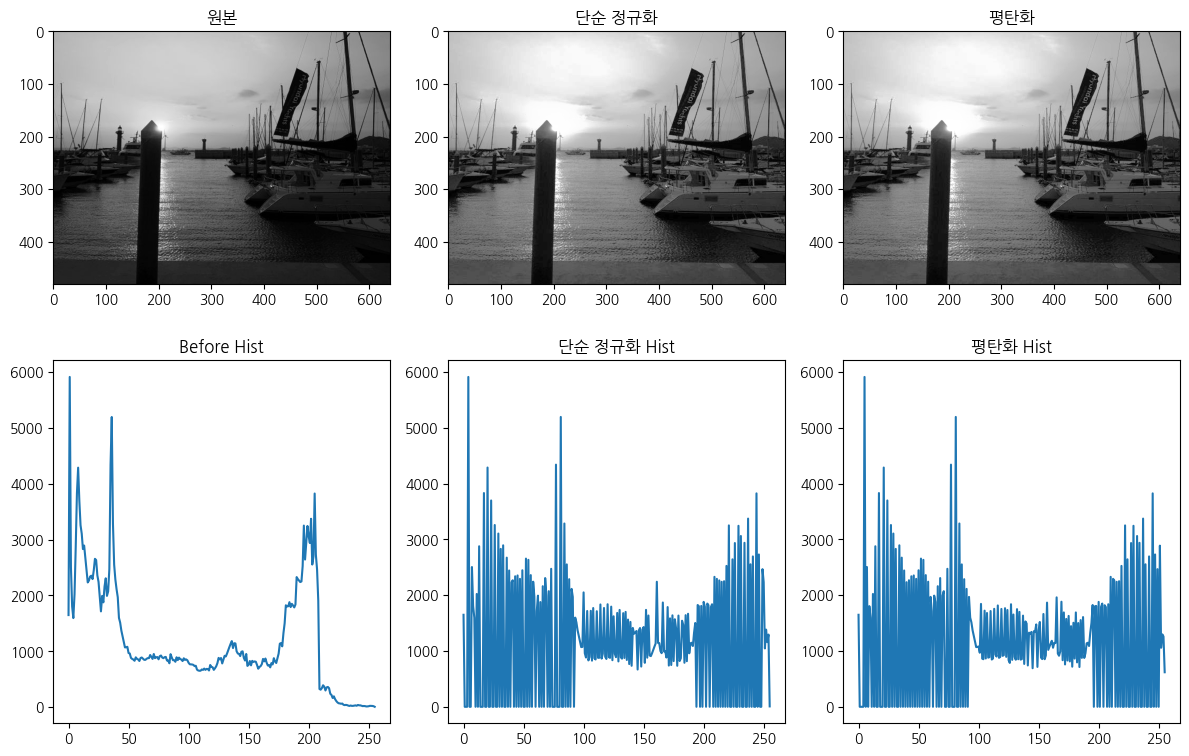

In [6]:
#--① 대상 영상으로 그레이 스케일로 읽기
img = cv2.imread('../Images/yate.jpg', cv2.IMREAD_GRAYSCALE)


rows, cols = img.shape[:2]
#--② 이퀄라이즈 연산을 직접 적용
hist = cv2.calcHist([img], [0], None, [256], [0, 256])   # 원본 히스토그램
cdf = hist.cumsum()                                      # 누적 히스토그램
cdf_m = np.ma.masked_equal(cdf, 0)                       # 0인 값 제외

# 직접 히스토그램 평활화 공식
cdf_m = (cdf_m - cdf_m.min()) / (cdf_m.max() - cdf_m.min()) * 255
cdf = np.ma.filled(cdf_m, 0).astype('uint8')             # 다시 uint8로 변환
print("cdf shape:", cdf.shape)
img2 = cdf[img]                                         # 픽셀값 매핑

#--③ OpenCV API로 이퀄라이즈 히스토그램 적용
img3 = cv2.equalizeHist(img)

#--④ 이퀄라이즈 결과 히스토그램 계산
hist2 = cv2.calcHist([img2], [0], None, [256], [0, 256])
hist3 = cv2.calcHist([img3], [0], None, [256], [0, 256])

#--⑤ cv2.imshow 없이 유틸 함수로 출력
titles_ = [
    '원본',
    '단순 정규화',
    '평탄화',
    'Before Hist',
    '단순 정규화 Hist',
    '평탄화 Hist'
]
images_ = [img, img2, img3]
plots_ = [hist, hist2, hist3]
cmap_ = ['gray']
printPlotImage(2, 3, titles_, plots_, images_, cmap_)

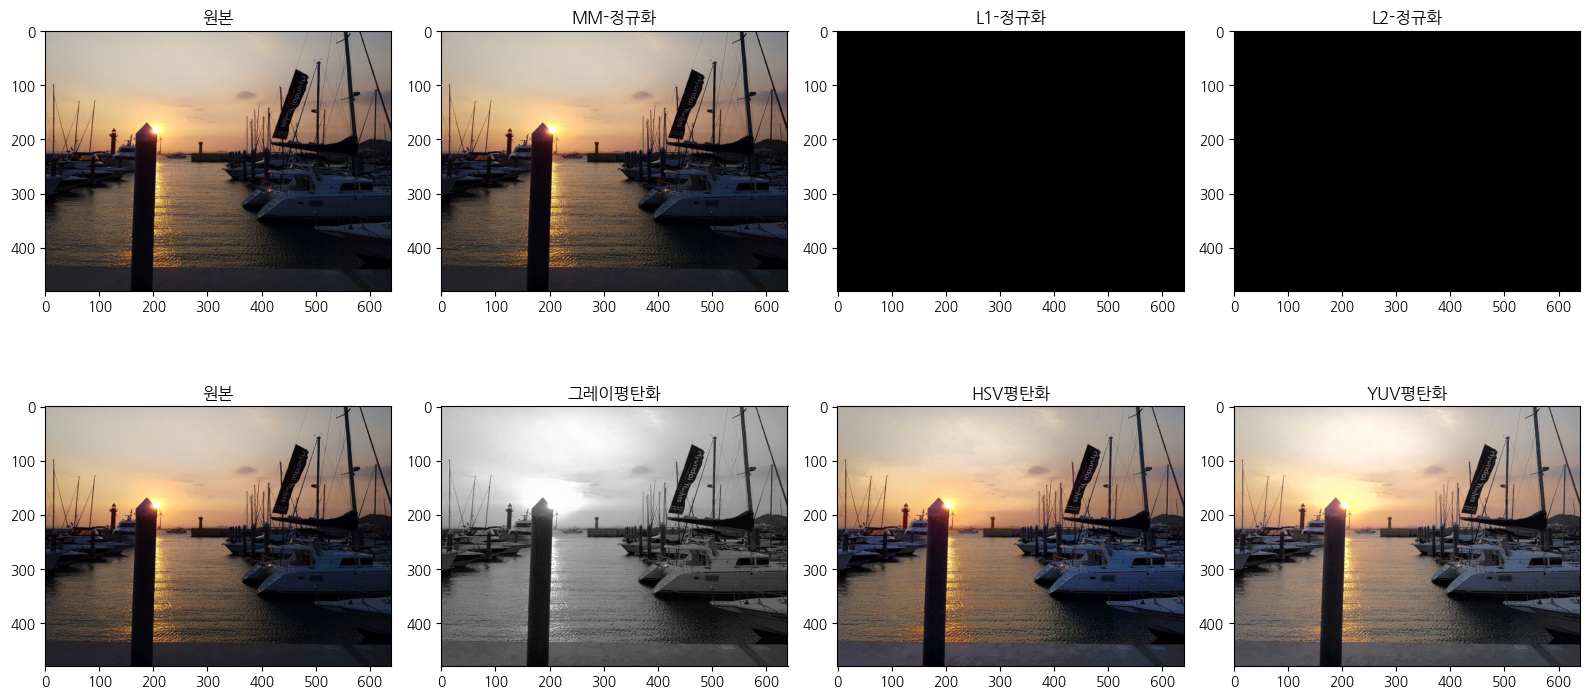

In [7]:
## ============================================================
## 정규화 + 평탄화 비교 시각화
## ============================================================

## 이미지 읽기
colorNP = cv2.imread('../Images/yate.jpg')

if colorNP is None:
    print('이미지를 불러오지 못했습니다. 경로를 확인하세요.')

else:
    ## OpenCV는 BGR로 읽으니까 matplotlib 출력용 RGB로 변환
    rgbNP = cv2.cvtColor(colorNP, cv2.COLOR_BGR2RGB)

    ## ============================================================
    ## [1] 정규화
    ## ============================================================

    ## MM 정규화
    mmNP = cv2.normalize(rgbNP, None, 0, 255, cv2.NORM_MINMAX)

    ## L1 정규화
    l1NP = cv2.normalize(rgbNP, None, 0, 255, cv2.NORM_L1)

    ## L2 정규화
    l2NP = cv2.normalize(rgbNP, None, 0, 255, cv2.NORM_L2)

    ## 출력용 uint8 변환
    mmNP = mmNP.astype(np.uint8)
    l1NP = l1NP.astype(np.uint8)
    l2NP = l2NP.astype(np.uint8)

    normNPs = [mmNP, l1NP, l2NP]


    ## ============================================================
    ## [2] 히스토그램 평탄화
    ## ============================================================

    ## [1] GRAY
    grayNP = cv2.cvtColor(colorNP, cv2.COLOR_BGR2GRAY)
    grayNP = cv2.equalizeHist(grayNP)

    ## [2] HSV
    hsvNP = cv2.cvtColor(colorNP, cv2.COLOR_BGR2HSV)
    hsvNP[:, :, 2] = cv2.equalizeHist(hsvNP[:, :, 2])

    ## [3] YUV
    yuvNP = cv2.cvtColor(colorNP, cv2.COLOR_BGR2YUV)
    yuvNP[:, :, 0] = cv2.equalizeHist(yuvNP[:, :, 0])


    ## ============================================================
    ## 평탄화 후 컬러스페이스 변환
    ## ============================================================

    equalNPs = [grayNP, hsvNP, yuvNP]

    flags = [
        cv2.COLOR_GRAY2RGB,
        cv2.COLOR_HSV2RGB,
        cv2.COLOR_YUV2RGB
    ]

    equalNPs = [
        cv2.cvtColor(imgNP, flag)
        for imgNP, flag in zip(equalNPs, flags)
    ]


    ## ============================================================
    ## 시각화
    ## ============================================================

    titles_ = [
        '원본', 'MM-정규화', 'L1-정규화', 'L2-정규화',
        '원본', '그레이평탄화', 'HSV평탄화', 'YUV평탄화'
    ]

    plots_ = []

    images_ = [rgbNP] + normNPs + [rgbNP] + equalNPs

    cmap_ = [None]

    printPlotImage(2, 4, titles_, plots_, images_, cmap_)

In [4]:
grayNP= cv2.imread(IMG_FILE, cv2.IMREAD_GRAYSCALE)
colorNP= cv2.imread(IMG_FILE)

[garyHist]  => 타입 : <class 'numpy.ndarray'>, 형태 : (256, 1),  차원 : 2D


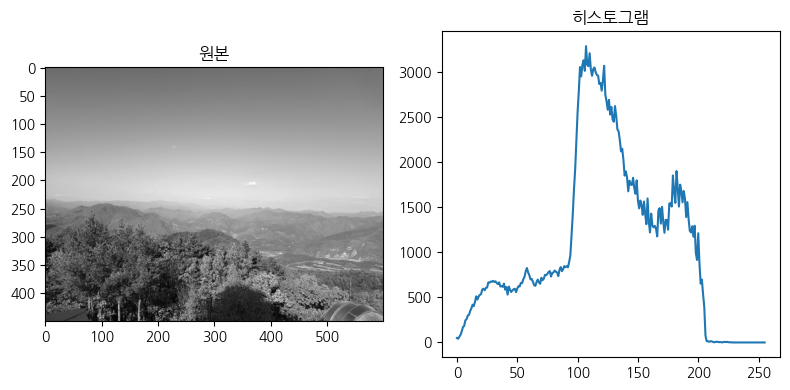

In [5]:
## 이미지 픽셀 데이터 분포 계산 : cv2.calcHist()
## =================================
## - 이미지객체, 채널 수, 마스크 => List
## - 값의 범위              => []
grayHist = cv2.calcHist([grayNP], [0], None, [256], [0, 256])

print(f'[garyHist]  => 타입 : {type(grayHist)}, 형태 : {grayHist.shape},  차원 : {grayHist.ndim}D')

## 시각화 : 원본이미지, 픽셀분포
titles_ = ['원본', '히스토그램']
plots_, images_ = [grayHist], [grayNP]
cmap_ = ['gray']

printPlotImage(1, 2, titles_, plots_, images_, cmap_)

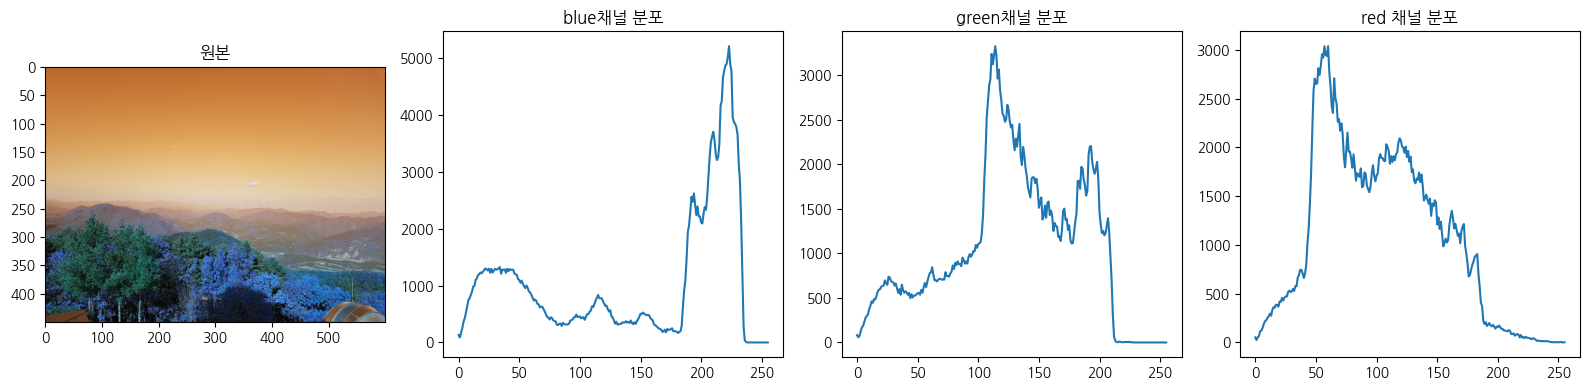

In [6]:
blueNP, greenNP, redNP = cv2.split(colorNP)

blueHist = cv2.calcHist([blueNP], [0], None, [256], [0, 256])
greenHist = cv2.calcHist([greenNP], [0], None, [256], [0, 256])
redHist = cv2.calcHist([redNP], [0], None, [256], [0, 256])

titles_ = ['원본', 'blue채널 분포', 'green채널 분포', 'red 채널 분포']
plots_, images_ = [blueHist, greenHist, redHist], [colorNP]
cmap_ = [None]

printPlotImage(1, 4, titles_, plots_, images_, cmap_)

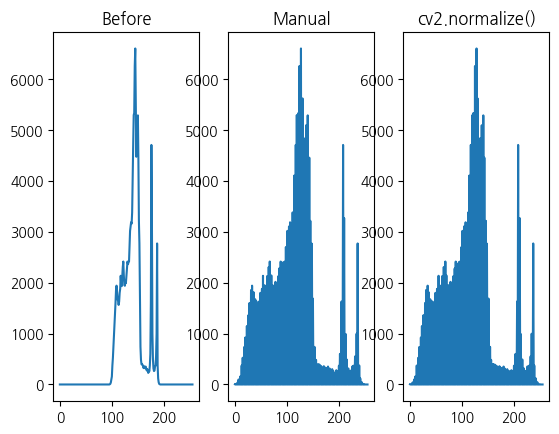

In [10]:
#--① 그레이 스케일로 영상 읽기
img = cv2.imread('../Images/abnormal.jpg', cv2.IMREAD_GRAYSCALE)

#--② 직접 연산한 정규화
img_f = img.astype(np.float32)
img_norm = ((img_f - img_f.min()) * (255) / (img_f.max() - img_f.min()))
img_norm = img_norm.astype(np.uint8)

#--③ OpenCV API를 이용한 정규화
img_norm2 = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX)

#--④ 히스토그램 계산
hist = cv2.calcHist([img], [0], None, [256], [0, 255])
hist_norm = cv2.calcHist([img_norm], [0], None, [256], [0, 255])
hist_norm2 = cv2.calcHist([img_norm2], [0], None, [256], [0, 255])

cv2.imshow('Before', img)
cv2.imshow('Manual', img_norm)
cv2.imshow('cv2.normalize()', img_norm2)

hists = {'Before' : hist, 'Manual':hist_norm, 'cv2.normalize()':hist_norm2}
for i, (k, v) in enumerate(hists.items()):
    plt.subplot(1,3,i+1)
    plt.title(k)
    plt.plot(v)
plt.show()

In [ ]:
## 픽셀 100 ~ 200 사이에 집중됨. 0~100/200~255픽셀 없음 ==> 정규화 진행
mmNP = cv2.normalize(mountNP, None, 0, 255, cv2.NORM_MINMAX)

mmHist = cv2.calcHist([mmNP], [0], None, [256], [0, 256])

printPlotImage(
    1, 4,
    ['원본이미지', 'MINMAX정규화', '원본 분포', '정규화 분포'],
    [mountHist, mmHist],
    [mountNP, mmNP],
    ['gray']
)

NameError: name 'mountHist' is not defined

: 